# Assessor scores

In [12]:
import os
import pickle
import pandas as pd
from pathlib import Path

In [13]:
BASE_DIR = Path("/home/rothermm/brain-diffuser")
SCORES_DIR = BASE_DIR / "results" / "assessor_scores"

SUBJECTS = [1, 2, 5, 7]
NETWORKS = ["emonet", "memnet"]
MODELS = ["vdvae", "versatile"]

In [14]:
def load_pickle(path):
    """Safely load a pickle file and return its contents."""
    with open(path, "rb") as f:
        return pickle.load(f)

def load_subject_scores(sub):
    """
    Load all scores for one subject.
    Returns dict: {network: {model: data}}
    """
    scores = {net: {} for net in NETWORKS}
    for net in NETWORKS:
        for model in MODELS:
            fname = f"{net}_{model}_sub{sub:02d}.pkl"
            fpath = SCORES_DIR / f"subj{sub:02d}" / fname
            if fpath.exists():
                scores[net][model] = load_pickle(fpath)
            else:
                print(f"⚠️ Missing file: {fpath}")
    return scores

In [15]:
all_scores = {}
for sub in SUBJECTS:
    all_scores[sub] = load_subject_scores(sub)

print("✅ Finished loading all subjects.")

✅ Finished loading all subjects.


In [16]:
def scores_to_dataframe(all_scores):
    """
    Convert nested dict of scores into a tidy DataFrame:
    Columns: subject, network, model, alpha, score
    """
    rows = []
    for sub, nets in all_scores.items():
        for net, models in nets.items():
            for model, alpha_dict in models.items():
                for alpha, scores in alpha_dict.items():
                    for s in scores:
                        rows.append({
                            "subject": sub,
                            "network": net,
                            "model": model,
                            "alpha": alpha,
                            "score": s
                        })
    return pd.DataFrame(rows)

df = scores_to_dataframe(all_scores)
df.head()

,subject,network,model,alpha,score
0,1,emonet,vdvae,alpha_0,0.515866
1,1,emonet,vdvae,alpha_0,0.353619
2,1,emonet,vdvae,alpha_0,0.513451
3,1,emonet,vdvae,alpha_0,0.361152
4,1,emonet,vdvae,alpha_0,0.491340


In [18]:
df["network"].unique(), df["model"].unique(), df["alpha"].unique(), df["subject"].unique()

(array(['emonet', 'memnet'], dtype=object),
 array(['vdvae', 'versatile'], dtype=object),
 array(['alpha_0', 'alpha_2', 'alpha_3', 'alpha_4', 'alpha_-2', 'alpha_-3',
        'alpha_-4', 'vdvae_image_to_image', 'clip_image_to_image'],
       dtype=object),
 array([1, 2, 5, 7]))

In [26]:
counts = (
    df.groupby(["subject", "alpha", "model","network"])
      .size()
      .reset_index(name="n_scores")
      .sort_values(["subject", "alpha"])
)
print(counts)

     subject                 alpha      model network  n_scores
0          1              alpha_-2      vdvae  emonet       982
1          1              alpha_-2      vdvae  memnet       982
2          1              alpha_-2  versatile  emonet       982
3          1              alpha_-2  versatile  memnet       982
4          1              alpha_-3      vdvae  emonet       982
..       ...                   ...        ...     ...       ...
123        7               alpha_4  versatile  memnet       982
124        7   clip_image_to_image  versatile  emonet       982
125        7   clip_image_to_image  versatile  memnet       982
126        7  vdvae_image_to_image      vdvae  emonet       982
127        7  vdvae_image_to_image      vdvae  memnet       982

[128 rows x 5 columns]


# SSIM

In [27]:
BASE_DIR = Path("/home/rothermm/brain-diffuser/results")
SSIM_DIR = BASE_DIR / "metrics" / "ssim"

MODELS = ["vdvae", "versatile_diffusion"]
NETWORKS = ["emonet", "memnet"]

In [28]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

def load_per_subject(model, network):
    """Load per-subject SSIM values (list of per-image scores)."""
    path = SSIM_DIR / model / f"per_subject_{network}.json"
    if not path.exists():
        print(f"⚠️ Missing: {path}")
        return None
    return load_json(path)

def load_summary(model, network):
    """Load summary statistics (mean/std per subject & alpha)."""
    path_csv = SSIM_DIR / model / f"summary_{network}.csv"
    if path_csv.exists():
        return pd.read_csv(path_csv)
    path_json = SSIM_DIR / model / f"summary_{network}.json"
    if path_json.exists():
        return pd.read_json(path_json)
    print(f"⚠️ Missing summary for {model}/{network}")
    return None

In [29]:
all_per_subject = {}
all_summary = []

for model in MODELS:
    all_per_subject[model] = {}
    for net in NETWORKS:
        all_per_subject[model][net] = load_per_subject(model, net)
        df = load_summary(model, net)
        if df is not None:
            df["model"] = model
            df["network"] = net
            all_summary.append(df)

# Merge all summaries into one DataFrame
summary_df = pd.concat(all_summary, ignore_index=True)
summary_df.head()


,model,network,subject,alpha,n,ssim_mean,ssim_std
0,vdvae,emonet,subj01,alpha -4,982,0.368175,0.131814
1,vdvae,emonet,subj01,alpha -2,982,0.538521,0.145273
2,vdvae,emonet,subj01,alpha 2,982,0.621569,0.162542
3,vdvae,emonet,subj01,alpha 4,982,0.472721,0.224061
4,vdvae,emonet,subj02,alpha -4,982,0.335554,0.133221


In [30]:
summary_df.columns

Index(['model', 'network', 'subject', 'alpha', 'n', 'ssim_mean', 'ssim_std'], dtype='object')

In [31]:
# Average SSIM across subjects, grouped by model & network
summary_df.groupby(["model", "network", "alpha"])["ssim_mean"].mean().unstack()


alpha                        alpha -2  alpha -4   alpha 2   alpha 4
model               network                                        
vdvae               emonet   0.567628  0.415893  0.636428  0.536715
                    memnet   0.624315  0.484127  0.585198  0.461994
versatile_diffusion emonet   0.197226  0.115700  0.178396  0.172283
                    memnet   0.202679  0.149808  0.188475  0.169458

In [33]:
# Inspect raw per-image SSIM values (nested dict)
all_per_subject["vdvae"]["emonet"].keys()  # subjects
all_per_subject["vdvae"]["emonet"]["subj01"].keys()  # alpha conditions
len(all_per_subject["vdvae"]["emonet"]["subj01"]["alpha -2"])  # number of images


982

# Human data

In [34]:
import pandas as pd
from pathlib import Path

# Path to detrended human data
csv_path = Path("/home/rothermm/brain-diffuser/data/human_data/human_df_detrended.csv")

# Load CSV
df_human = pd.read_csv(csv_path)

print("✅ Loaded detrended human data:", csv_path)
print(df_human.head())


✅ Loaded detrended human data: /home/rothermm/brain-diffuser/data/human_data/human_df_detrended.csv
   SubjectID Condition  ValenceRating  MemorabilityRating
0          1    alpha0      56.750567           61.706183
1          1    alpha0      67.020776           64.248593
2          1    alpha0      49.378485           54.663503
3          1    alpha0      47.479945           13.150913
4          1    alpha0      51.700154           55.375823


In [35]:
# Basic info about the DataFrame
print("\n--- Shape & Columns ---")
print(df_human.shape)
print(df_human.columns.tolist())

print("\n--- Data Types ---")
print(df_human.dtypes)

print("\n--- First 10 rows ---")
print(df_human.head(10))

# Unique subjects and conditions
print("\n--- Unique Subjects ---")
print(df_human["SubjectID"].unique())

print("\n--- Unique Conditions ---")
print(df_human["Condition"].unique())

# Counts per subject & condition
print("\n--- Counts per Subject/Condition ---")
counts = df_human.groupby(["SubjectID", "Condition"]).size().reset_index(name="n")
print(counts.head(20))

# Summary statistics
print("\n--- Summary Statistics ---")
print(df_human.describe())

# Pivot table: average ratings per subject × condition
pivot_val = df_human.pivot_table(
    index="SubjectID",
    columns="Condition",
    values="ValenceRating",
    aggfunc="mean"
)

pivot_mem = df_human.pivot_table(
    index="SubjectID",
    columns="Condition",
    values="MemorabilityRating",
    aggfunc="mean"
)

print("\n--- Average Valence Ratings (per subject × condition) ---")
print(pivot_val.head())

print("\n--- Average Memorability Ratings (per subject × condition) ---")
print(pivot_mem.head())



--- Shape & Columns ---
(6480, 4)
['SubjectID', 'Condition', 'ValenceRating', 'MemorabilityRating']

--- Data Types ---
SubjectID               int64
Condition              object
ValenceRating         float64
MemorabilityRating    float64
dtype: object

--- First 10 rows ---
   SubjectID Condition  ValenceRating  MemorabilityRating
0          1    alpha0      56.750567           61.706183
1          1    alpha0      67.020776           64.248593
2          1    alpha0      49.378485           54.663503
3          1    alpha0      47.479945           13.150913
4          1    alpha0      51.700154           55.375823
5          1    alpha0      76.201613           70.128233
6          1    alpha0      62.890572           57.820642
7          1    alpha0      52.535782           36.685552
8          1    alpha0      68.305991           48.715462
9          1    alpha0      62.351200           91.847872

--- Unique Subjects ---
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]

--

# Images

In [36]:
BASE_DIR = Path("/home/rothermm/brain-diffuser")
ASSESSOR_DIR = BASE_DIR / "assessors"
DEFAULT_TEST_NPY = BASE_DIR / "data" / "processed_data" / "subj01" / "nsd_test_stim_sub1.npy"
OUT_DIR = BASE_DIR / "results" / "assessor_scores" 
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [38]:
import matplotlib.pyplot as plt
import numpy as np

def show_first_images(npy_path, n=5):
    imgs = np.load(npy_path)  # (N, H, W, 3)
    assert imgs.ndim == 4 and imgs.shape[-1] == 3, f"Expected (N,H,W,3), got {imgs.shape}"
    
    plt.figure(figsize=(15, 3))
    for i in range(min(n, imgs.shape[0])):
        plt.subplot(1, n, i+1)
        plt.imshow(np.clip(imgs[i], 0, 1))  # assumes float in [0,1]; works for uint8 too
        plt.axis("off")
        plt.title(f"Image {i+1}")
    plt.tight_layout()
    plt.show()

# Example usage:
# show_first_images(DEFAULT_TEST_NPY, n=5)


Loaded 982 images of shape (425, 425, 3) from /home/rothermm/brain-diffuser/data/processed_data/subj01/nsd_test_stim_sub1.npy


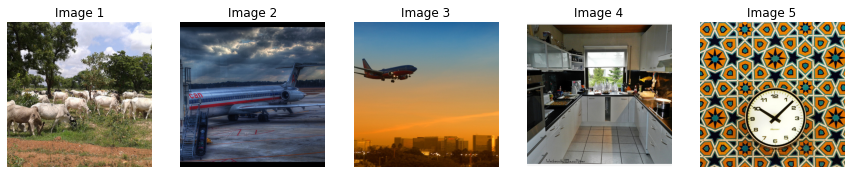

In [41]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- Paths (same as your repo) ---
BASE_DIR = Path("/home/rothermm/brain-diffuser")
DATA_DIR = BASE_DIR / "data" / "processed_data"
npy_path = DATA_DIR / "subj01" / "nsd_test_stim_sub1.npy"

# --- Helper to safely convert to uint8 for display ---
def safe_to_uint8(img: np.ndarray) -> np.ndarray:
    if img.dtype == np.uint8:
        return img
    arr = img.astype(np.float32)
    if arr.max() <= 1.001 and arr.min() >= -0.001:   # float in [0,1]
        arr = np.clip(arr, 0.0, 1.0) * 255.0
    else:  # fallback: min-max normalize
        imin, imax = float(arr.min()), float(arr.max())
        if imax > imin:
            arr = (arr - imin) / (imax - imin) * 255.0
        else:
            arr = np.zeros_like(arr)
    return np.clip(arr, 0, 255).astype(np.uint8)

# --- Load and show ---
imgs = np.load(npy_path)   # shape (N, H, W, 3)
print(f"Loaded {imgs.shape[0]} images of shape {imgs.shape[1:]} from {npy_path}")

plt.figure(figsize=(15, 3))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    ax.imshow(safe_to_uint8(imgs[i]))
    ax.axis("off")
    ax.set_title(f"Image {i+1}")
plt.show()


In [43]:
#!/usr/bin/env python
# coding: utf-8

import pickle
from pathlib import Path
import pandas as pd

# =============================================================================
# Paths
# =============================================================================
BASE_DIR = Path("/home/rothermm/brain-diffuser")
SCORES_DIR = BASE_DIR / "results" / "assessor_scores"

FILES = ["emonet_original.pkl", "memnet_original.pkl"]

# =============================================================================
# Load helper
# =============================================================================
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# =============================================================================
# Load both files
# =============================================================================
all_scores = {}
for fname in FILES:
    fpath = SCORES_DIR / fname
    data = load_pickle(fpath)
    key = fname.replace("_original.pkl", "")
    all_scores[key] = data["score"]
    print(f"✅ Loaded {fname}: {len(all_scores[key])} scores")

# Convert to DataFrame for exploration
df_scores = pd.DataFrame({
    "emonet": all_scores["emonet"],
    "memnet": all_scores["memnet"]
})

print("\n--- Shape & Columns ---")
print(df_scores.shape)
print(df_scores.columns.tolist())

print("\n--- First 5 rows ---")
print(df_scores.head())

print("\n--- Summary statistics ---")
print(df_scores.describe())

# Correlation between EmoNet and MemNet scores
corr = df_scores.corr()
print("\n--- Correlation between assessors ---")
print(corr)


✅ Loaded emonet_original.pkl: 982 scores
✅ Loaded memnet_original.pkl: 982 scores

--- Shape & Columns ---
(982, 2)
['emonet', 'memnet']

--- First 5 rows ---
     emonet    memnet
0  0.612634  0.582780
1  0.424347  0.680876
2  0.806251  0.866888
3  0.564422  0.720724
4  0.671714  0.677569

--- Summary statistics ---
           emonet      memnet
count  982.000000  982.000000
mean     0.561636    0.755822
std      0.112021    0.076869
min      0.230592    0.533969
25%      0.480218    0.701691
50%      0.564042    0.766509
75%      0.640484    0.812867
max      0.919951    0.948824

--- Correlation between assessors ---
          emonet    memnet
emonet  1.000000 -0.029476
memnet -0.029476  1.000000


# pixcorr

In [10]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

BASE = Path("/home/rothermm/brain-diffuser/results/metrics/pixcorr")
SUBJ = "subj01"  # change as needed

with open(BASE / SUBJ / "per_image.json", "r") as f:
    per_image = json.load(f)

# Quick peek
list(per_image.keys())[:5]


['intra:vdvae:emonet:alpha_-4_vs_alpha_0',
 'intra:vdvae:emonet:alpha_-2_vs_alpha_0',
 'intra:vdvae:emonet:alpha_+2_vs_alpha_0',
 'intra:vdvae:emonet:alpha_+4_vs_alpha_0',
 'intra:vdvae:memnet:alpha_-4_vs_alpha_0']

In [19]:
list(per_image.keys())

['intra:vdvae:emonet:alpha_-4_vs_alpha_0',
 'intra:vdvae:emonet:alpha_-2_vs_alpha_0',
 'intra:vdvae:emonet:alpha_+2_vs_alpha_0',
 'intra:vdvae:emonet:alpha_+4_vs_alpha_0',
 'intra:vdvae:memnet:alpha_-4_vs_alpha_0',
 'intra:vdvae:memnet:alpha_-2_vs_alpha_0',
 'intra:vdvae:memnet:alpha_+2_vs_alpha_0',
 'intra:vdvae:memnet:alpha_+4_vs_alpha_0',
 'intra:versatile_diffusion:emonet:alpha_-4_vs_alpha_0',
 'intra:versatile_diffusion:emonet:alpha_-2_vs_alpha_0',
 'intra:versatile_diffusion:emonet:alpha_+2_vs_alpha_0',
 'intra:versatile_diffusion:emonet:alpha_+4_vs_alpha_0',
 'intra:versatile_diffusion:memnet:alpha_-4_vs_alpha_0',
 'intra:versatile_diffusion:memnet:alpha_-2_vs_alpha_0',
 'intra:versatile_diffusion:memnet:alpha_+2_vs_alpha_0',
 'intra:versatile_diffusion:memnet:alpha_+4_vs_alpha_0',
 'alpha0_vs_originals:vdvae:emonet',
 'alpha0_vs_originals:vdvae:memnet',
 'alpha0_vs_originals:versatile_diffusion:emonet',
 'alpha0_vs_originals:versatile_diffusion:memnet',
 'alpha0_vs_vdvae_i2i:vd

In [11]:
def intra_key(model, network, alpha_key):
    # alpha_key examples: "alpha_-4", "alpha_-2", "alpha_+2", "alpha_+4"
    return f"intra:{model}:{network}:{alpha_key}_vs_alpha_0"

def a0_vs_originals_key(model, network):
    return f"alpha0_vs_originals:{model}:{network}"

def a0_vs_i2i_key(model, network):
    return f"alpha0_vs_vdvae_i2i:{model}:{network}"

def get_vals(key):
    """Fetch and return finite-only numpy array for a given comparison key.
       Returns None if key missing or empty."""
    if key not in per_image:
        return None
    arr = np.asarray(per_image[key], dtype=float)
    arr = arr[np.isfinite(arr)]
    return arr if arr.size else None

def scatter_xy(x, y, title, xlabel, ylabel):
    """Simple scatter with y=x reference."""
    n = min(len(x), len(y))
    if n == 0:
        print(f"[skip] nothing to plot for: {title}")
        return
    x = x[:n]
    y = y[:n]
    plt.figure(figsize=(5,5))
    plt.scatter(x, y, s=10, alpha=0.6)
    lo = min(float(np.min(x)), float(np.min(y)))
    hi = max(float(np.max(x)), float(np.max(y)))
    pad = 0.02 * (hi - lo if hi > lo else 1.0)
    plt.plot([lo-pad, hi+pad], [lo-pad, hi+pad], linestyle="--")
    plt.xlim(lo-pad, hi+pad)
    plt.ylim(lo-pad, hi+pad)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()


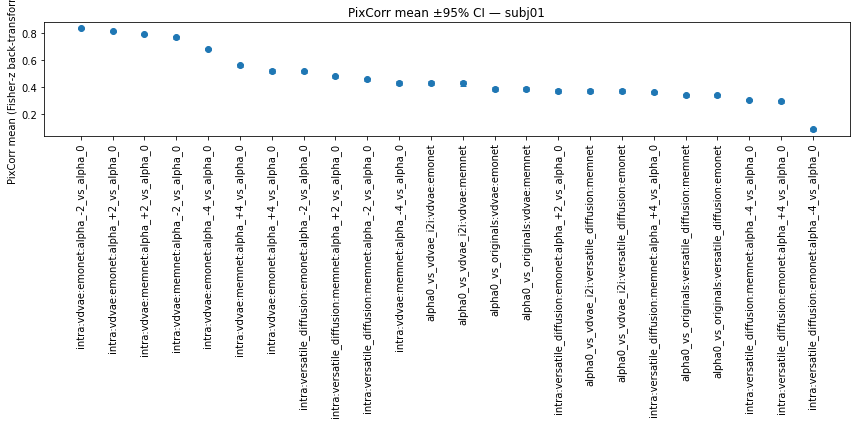

In [4]:
# %% Bar chart: mean_r with 95% CI for all comparisons (sorted)
df_plot = dfp.sort_values("mean_r", ascending=False).reset_index(drop=True)
x = np.arange(len(df_plot))
y = df_plot["mean_r"].values
yerr = np.vstack([y - df_plot["ci_low_r"].values, df_plot["ci_high_r"].values - y])

plt.figure(figsize=(12, 6))
plt.errorbar(x, y, yerr=yerr, fmt="o", capsize=3)
plt.xticks(x, df_plot["comparison"], rotation=90)
plt.ylabel("PixCorr mean (Fisher‑z back‑transformed)")
plt.title(f"PixCorr mean ±95% CI — {SUBJ}")
plt.tight_layout()
plt.show()


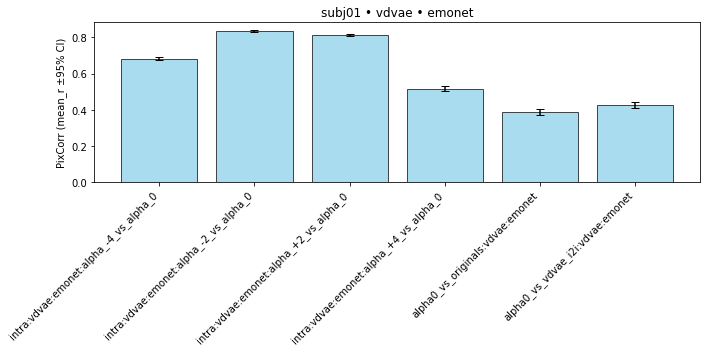

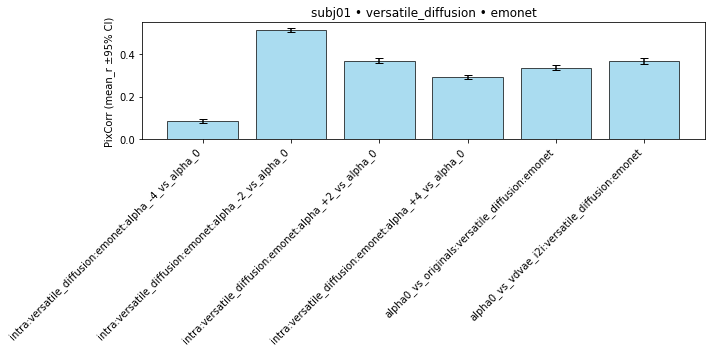

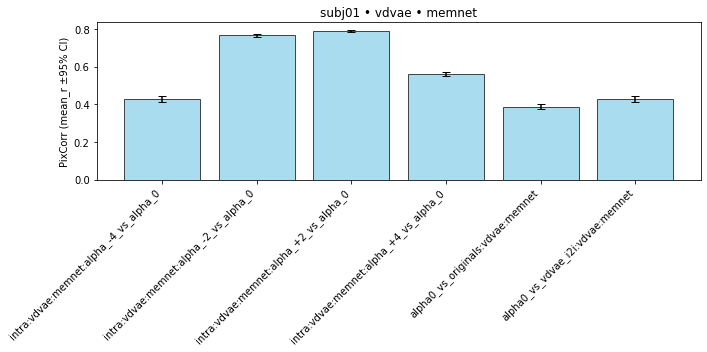

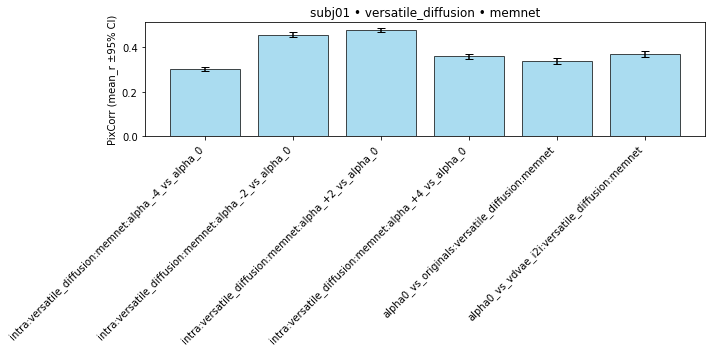

In [13]:
# %% Load summary CSV for one subject
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

BASE = Path("/home/rothermm/brain-diffuser/results/metrics/pixcorr")
SUBJ = "subj01"
df = pd.read_csv(BASE / SUBJ / "summary.csv")

# Parse keys → tidy columns
import re
def parse_key(k: str):
    m = re.match(r"intra:(.*?):(.*?):(.*?)_vs_alpha_0$", k)
    if m:
        model, network, alpha_key = m.groups()
        return {"type":"intra", "model":model, "network":network, "alpha":alpha_key}
    m = re.match(r"alpha0_vs_originals:(.*?):(.*?)$", k)
    if m:
        model, network = m.groups()
        return {"type":"a0_vs_originals", "model":model, "network":network, "alpha":"0"}
    m = re.match(r"alpha0_vs_vdvae_i2i:(.*?):(.*?)$", k)
    if m:
        model, network = m.groups()
        return {"type":"a0_vs_i2i", "model":model, "network":network, "alpha":"0"}
    return {"type":"unknown","model":None,"network":None,"alpha":None}

parsed = df["comparison"].apply(parse_key).apply(pd.Series)
dfp = pd.concat([df, parsed], axis=1)

# %% Function to make one barplot per model×network
def plot_bars(d, model, network):
    dsel = d[(d["model"]==model)&(d["network"]==network)].copy()
    if dsel.empty:
        print(f"[skip] {model} {network} (no data)")
        return
    
    # order by type, alpha
    order = []
    for t in ["intra","a0_vs_originals","a0_vs_i2i"]:
        for _, row in dsel[dsel["type"]==t].iterrows():
            order.append(row["comparison"])
    dsel = dsel.set_index("comparison").loc[order].reset_index()

    y = dsel["mean_r"].values
    x = np.arange(len(dsel))
    yerr = np.vstack([y - dsel["ci_low_r"].values, dsel["ci_high_r"].values - y])

    plt.figure(figsize=(10,5))
    plt.bar(x, y, yerr=yerr, capsize=4, alpha=0.7, color="skyblue", edgecolor="black")
    plt.xticks(x, dsel["comparison"], rotation=45, ha="right")
    plt.ylabel("PixCorr (mean_r ±95% CI)")
    plt.title(f"{SUBJ} • {model} • {network}")
    plt.tight_layout()
    plt.show()

# %% Generate four plots
plot_bars(dfp, "vdvae", "emonet")
plot_bars(dfp, "versatile_diffusion", "emonet")
plot_bars(dfp, "vdvae", "memnet")
plot_bars(dfp, "versatile_diffusion", "memnet")


In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

BASE = Path("/home/rothermm/brain-diffuser/results/metrics/pixcorr")
SUBJ = "subj01"
df = pd.read_csv(BASE / SUBJ / "summary.csv")

def parse_key(k: str):
    m = re.match(r"intra:(.*?):(.*?):(.*?)_vs_alpha_0$", k)
    if m:
        model, network, alpha_key = m.groups()
        return {"type":"intra", "model":model, "network":network, "alpha":alpha_key}
    m = re.match(r"alpha0_vs_originals:(.*?):(.*?)$", k)
    if m:
        model, network = m.groups()
        return {"type":"a0_vs_originals", "model":model, "network":network, "alpha":"0"}
    m = re.match(r"alpha0_vs_vdvae_i2i:(.*?):(.*?)$", k)
    if m:
        model, network = m.groups()
        return {"type":"a0_vs_i2i", "model":model, "network":network, "alpha":"0"}
    return {"type":"unknown","model":None,"network":None,"alpha":None}

parsed = df["comparison"].apply(parse_key).apply(pd.Series)
dfp = pd.concat([df, parsed], axis=1)


In [15]:
def p_to_stars(p):
    if p is None or pd.isna(p):
        return "n/a"
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "ns"

def annotate_pvalues(ax, x, y, pvals):
    for xi, yi, p in zip(x, y, pvals):
        stars = p_to_stars(p)
        if p is None or pd.isna(p):
            ax.text(xi, yi, "n/a", ha="center", va="bottom", fontsize=9, rotation=0)
        else:
            ax.text(xi, yi, f"{stars}\n(p={p:.2e})", ha="center", va="bottom", fontsize=9)

def plot_bars_for_model_network(d, model, network, title_prefix=None):
    """One barplot for a given model×network showing all comparisons for that pair."""
    dsel = d[(d["model"]==model)&(d["network"]==network)].copy()
    if dsel.empty:
        print(f"[skip] {model} {network} (no data)")
        return

    # Order: all intra (sorted by alpha), then a0_vs_originals, then a0_vs_i2i
    order = []
    order += list(dsel[dsel["type"]=="intra"].sort_values("alpha")["comparison"])
    order += list(dsel[dsel["type"]=="a0_vs_originals"]["comparison"])
    order += list(dsel[dsel["type"]=="a0_vs_i2i"]["comparison"])
    dsel = dsel.set_index("comparison").loc[order].reset_index()

    x = np.arange(len(dsel))
    y = dsel["mean_r"].values
    yerr = np.vstack([y - dsel["ci_low_r"].values, dsel["ci_high_r"].values - y])
    pvals = dsel["p_value"].values

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x, y, yerr=yerr, capsize=4, alpha=0.8, edgecolor="black")
    ax.set_xticks(x)
    ax.set_xticklabels(dsel["comparison"], rotation=45, ha="right")
    ax.set_ylabel("PixCorr (mean_r ±95% CI)")
    title = f"{SUBJ} • {model} • {network}"
    if title_prefix:
        title = f"{title_prefix} — " + title
    ax.set_title(title)
    annotate_pvalues(ax, x, y + (np.max(yerr, axis=0) if len(yerr)>0 else 0), pvals)
    fig.tight_layout()
    plt.show()


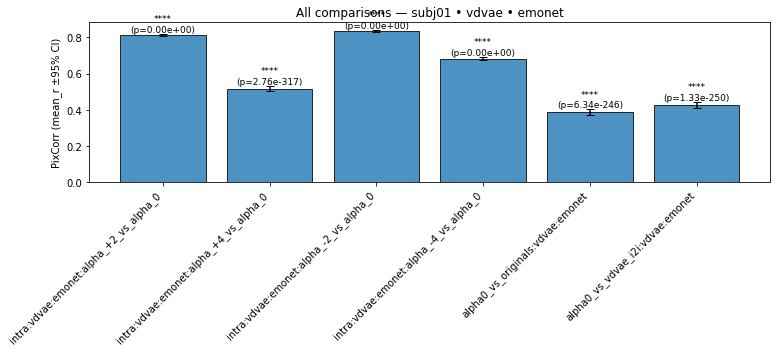

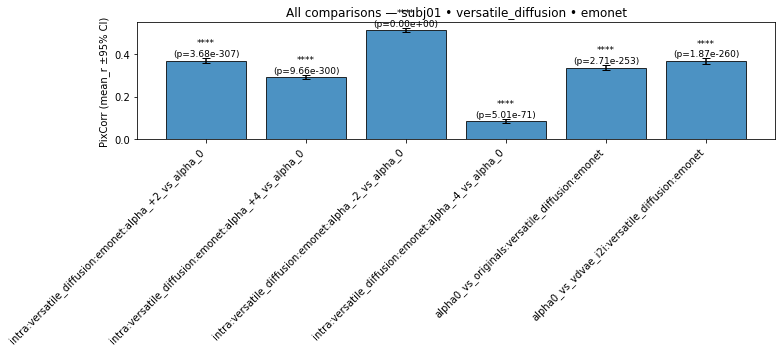

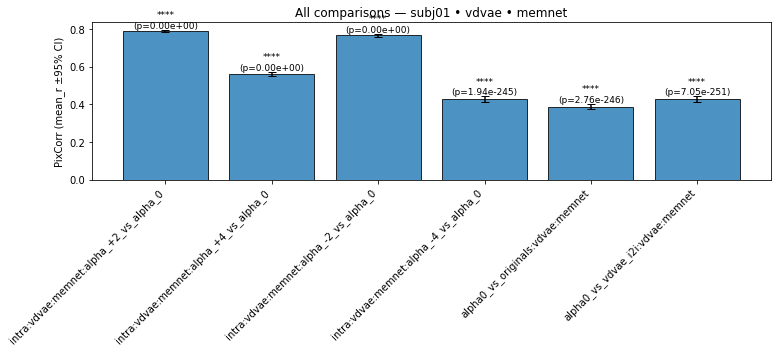

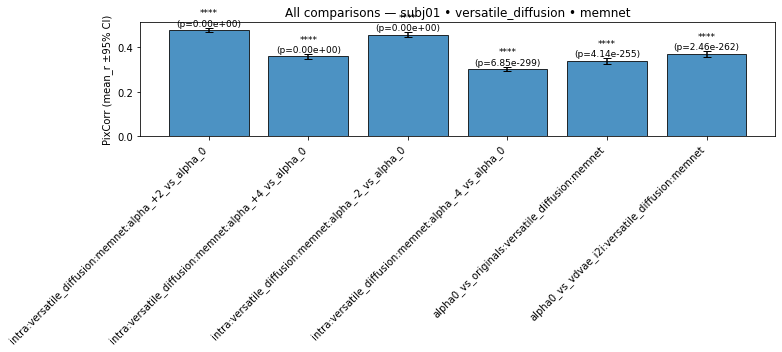

In [16]:
plot_bars_for_model_network(dfp, "vdvae", "emonet", title_prefix="All comparisons")
plot_bars_for_model_network(dfp, "versatile_diffusion", "emonet", title_prefix="All comparisons")
plot_bars_for_model_network(dfp, "vdvae", "memnet", title_prefix="All comparisons")
plot_bars_for_model_network(dfp, "versatile_diffusion", "memnet", title_prefix="All comparisons")


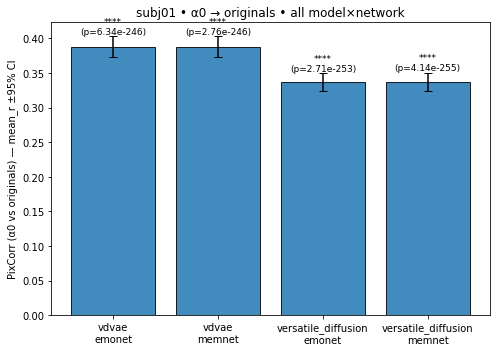

In [17]:
def plot_vs_originals_all(d):
    dsel = d[d["type"]=="a0_vs_originals"].copy()
    if dsel.empty:
        print("[skip] no alpha0_vs_originals rows")
        return
    # Consistent ordering
    order_pairs = [
        ("vdvae","emonet"),
        ("vdvae","memnet"),
        ("versatile_diffusion","emonet"),
        ("versatile_diffusion","memnet"),
    ]
    dsel["pair"] = list(zip(dsel["model"], dsel["network"]))
    dsel = dsel.set_index("pair").reindex(order_pairs).reset_index()
    labels = [f"{m}\n{n}" for m, n in dsel["pair"]]

    x = np.arange(len(dsel))
    y = dsel["mean_r"].values
    yerr = np.vstack([y - dsel["ci_low_r"].values, dsel["ci_high_r"].values - y])
    pvals = dsel["p_value"].values

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(x, y, yerr=yerr, capsize=4, alpha=0.85, edgecolor="black")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_ylabel("PixCorr (α0 vs originals) — mean_r ±95% CI")
    ax.set_title(f"{SUBJ} • α0 → originals • all model×network")
    annotate_pvalues(ax, x, y + (np.max(yerr, axis=0) if len(yerr)>0 else 0), pvals)
    fig.tight_layout()
    plt.show()

plot_vs_originals_all(dfp)


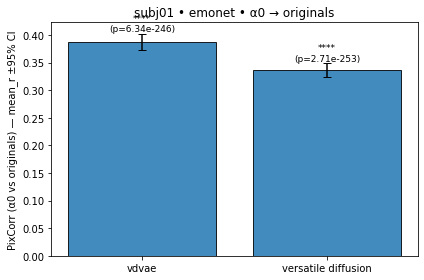

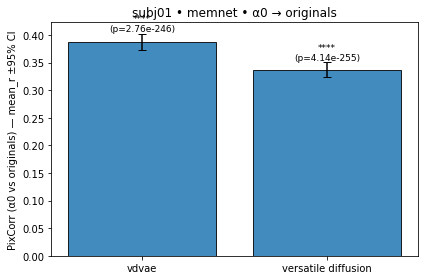

In [18]:
def plot_vs_originals_by_network(d, network):
    dsel = d[(d["type"]=="a0_vs_originals")&(d["network"]==network)].copy()
    if dsel.empty:
        print(f"[skip] no α0_vs_originals rows for network={network}")
        return
    dsel = dsel.set_index("model").loc[["vdvae","versatile_diffusion"]].reset_index()

    x = np.arange(len(dsel))
    y = dsel["mean_r"].values
    yerr = np.vstack([y - dsel["ci_low_r"].values, dsel["ci_high_r"].values - y])
    pvals = dsel["p_value"].values
    labels = dsel["model"].str.replace("_"," ").tolist()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(x, y, yerr=yerr, capsize=4, alpha=0.85, edgecolor="black")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("PixCorr (α0 vs originals) — mean_r ±95% CI")
    ax.set_title(f"{SUBJ} • {network} • α0 → originals")
    annotate_pvalues(ax, x, y + (np.max(yerr, axis=0) if len(yerr)>0 else 0), pvals)
    fig.tight_layout()
    plt.show()

plot_vs_originals_by_network(dfp, "emonet")
plot_vs_originals_by_network(dfp, "memnet")


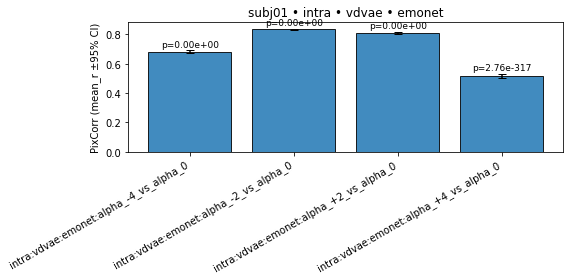

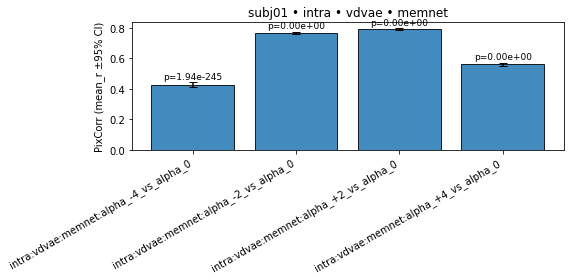

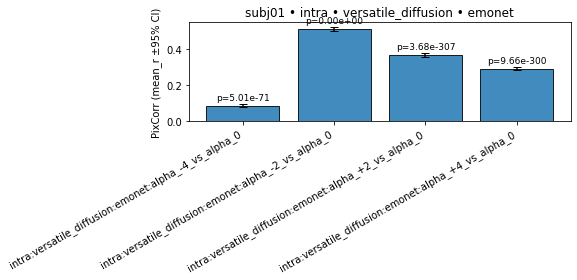

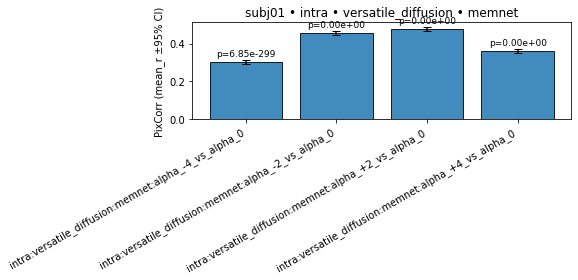

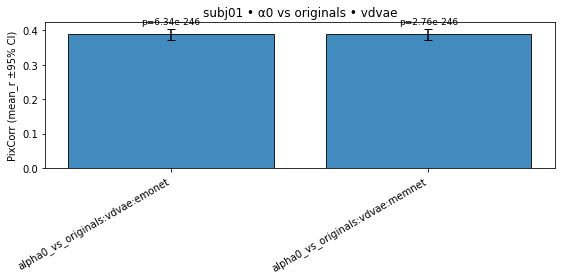

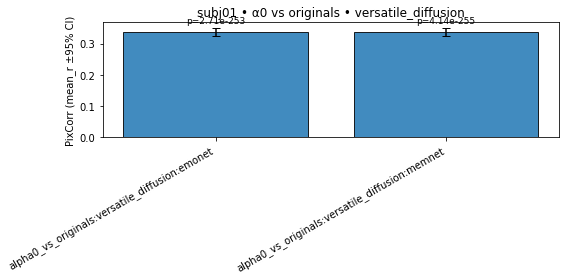

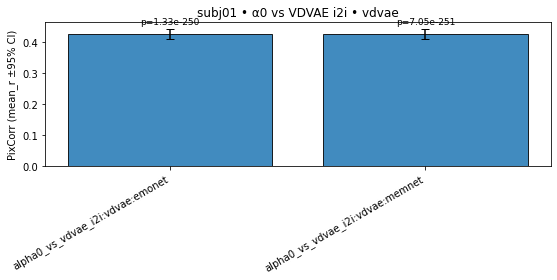

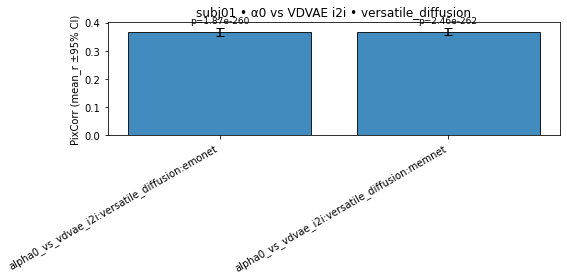

In [20]:
# %% setup
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = Path("/home/rothermm/brain-diffuser/results/metrics/pixcorr")
SUBJ = "subj01"
df = pd.read_csv(BASE / SUBJ / "summary.csv")

def plot_keys(keys, title):
    d = df[df["comparison"].isin(keys)].copy()
    if d.empty:
        print(f"[skip] {title} (no rows)")
        return
    # keep the user-specified order
    d["order"] = d["comparison"].apply(lambda k: keys.index(k))
    d = d.sort_values("order")

    x = np.arange(len(d))
    y = d["mean_r"].values
    yerr = np.vstack([y - d["ci_low_r"].values, d["ci_high_r"].values - y])
    pvals = d["p_value"].values

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x, y, yerr=yerr, capsize=4, edgecolor="black", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(d["comparison"], rotation=30, ha="right")
    ax.set_ylabel("PixCorr (mean_r ±95% CI)")
    ax.set_title(f"{SUBJ} • {title}")

    # annotate p-values
    offsets = np.max(yerr, axis=0) if yerr.size else np.zeros_like(y)
    for xi, yi, off, p in zip(x, y, offsets, pvals):
        label = "n/a" if pd.isna(p) else f"p={p:.2e}"
        ax.text(xi, yi + off + 0.01, label, ha="center", va="bottom", fontsize=9)
    fig.tight_layout()
    plt.show()

# %% groups exactly as requested

plot_keys([
 'intra:vdvae:emonet:alpha_-4_vs_alpha_0',
 'intra:vdvae:emonet:alpha_-2_vs_alpha_0',
 'intra:vdvae:emonet:alpha_+2_vs_alpha_0',
 'intra:vdvae:emonet:alpha_+4_vs_alpha_0',
], "intra • vdvae • emonet")

plot_keys([
 'intra:vdvae:memnet:alpha_-4_vs_alpha_0',
 'intra:vdvae:memnet:alpha_-2_vs_alpha_0',
 'intra:vdvae:memnet:alpha_+2_vs_alpha_0',
 'intra:vdvae:memnet:alpha_+4_vs_alpha_0',
], "intra • vdvae • memnet")

plot_keys([
 'intra:versatile_diffusion:emonet:alpha_-4_vs_alpha_0',
 'intra:versatile_diffusion:emonet:alpha_-2_vs_alpha_0',
 'intra:versatile_diffusion:emonet:alpha_+2_vs_alpha_0',
 'intra:versatile_diffusion:emonet:alpha_+4_vs_alpha_0',
], "intra • versatile_diffusion • emonet")

plot_keys([
 'intra:versatile_diffusion:memnet:alpha_-4_vs_alpha_0',
 'intra:versatile_diffusion:memnet:alpha_-2_vs_alpha_0',
 'intra:versatile_diffusion:memnet:alpha_+2_vs_alpha_0',
 'intra:versatile_diffusion:memnet:alpha_+4_vs_alpha_0',
], "intra • versatile_diffusion • memnet")

plot_keys([
 'alpha0_vs_originals:vdvae:emonet',
 'alpha0_vs_originals:vdvae:memnet',
], "α0 vs originals • vdvae")

plot_keys([
 'alpha0_vs_originals:versatile_diffusion:emonet',
 'alpha0_vs_originals:versatile_diffusion:memnet',
], "α0 vs originals • versatile_diffusion")

plot_keys([
 'alpha0_vs_vdvae_i2i:vdvae:emonet',
 'alpha0_vs_vdvae_i2i:vdvae:memnet',
], "α0 vs VDVAE i2i • vdvae")

plot_keys([
 'alpha0_vs_vdvae_i2i:versatile_diffusion:emonet',
 'alpha0_vs_vdvae_i2i:versatile_diffusion:memnet',
], "α0 vs VDVAE i2i • versatile_diffusion")


saved: /home/rothermm/brain-diffuser/results/graphs/pix_corr/intra_vdvae_emonet.png


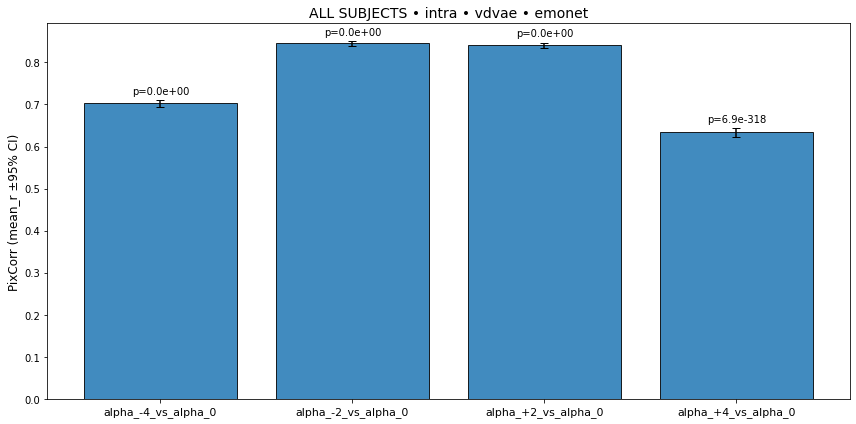

saved: /home/rothermm/brain-diffuser/results/graphs/pix_corr/intra_vdvae_memnet.png


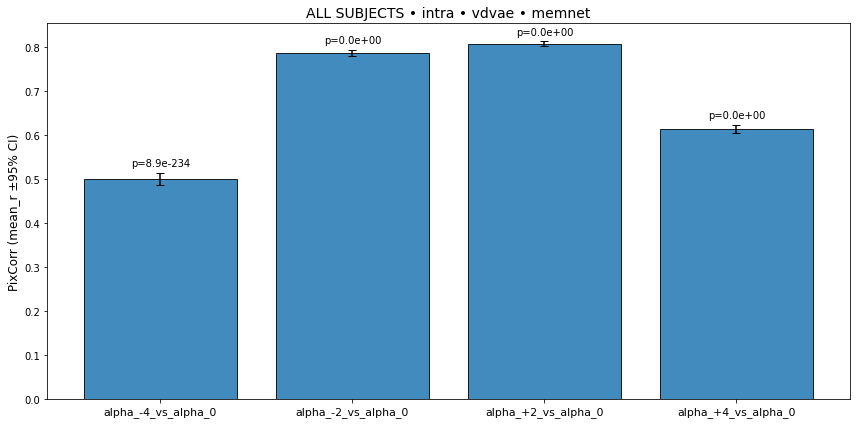

saved: /home/rothermm/brain-diffuser/results/graphs/pix_corr/intra_versatile_emonet.png


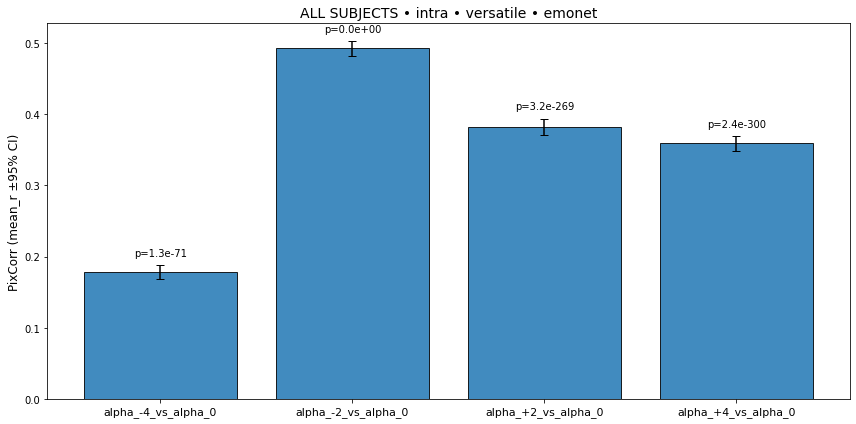

saved: /home/rothermm/brain-diffuser/results/graphs/pix_corr/intra_versatile_memnet.png


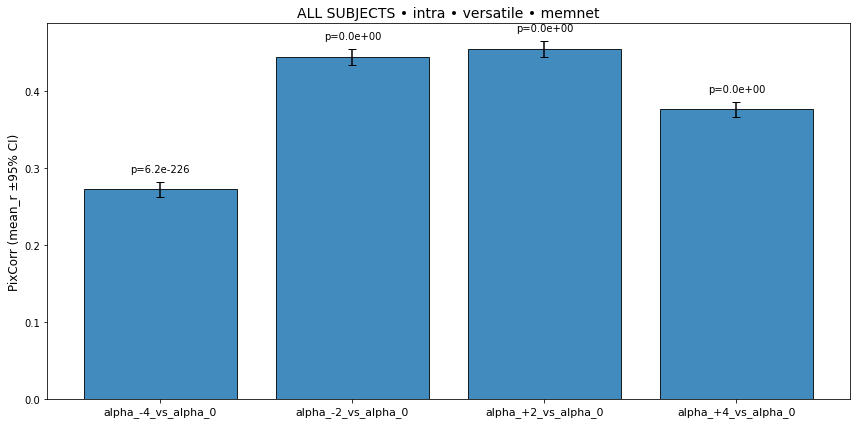

saved: /home/rothermm/brain-diffuser/results/graphs/pix_corr/a0_vs_originals_vdvae.png


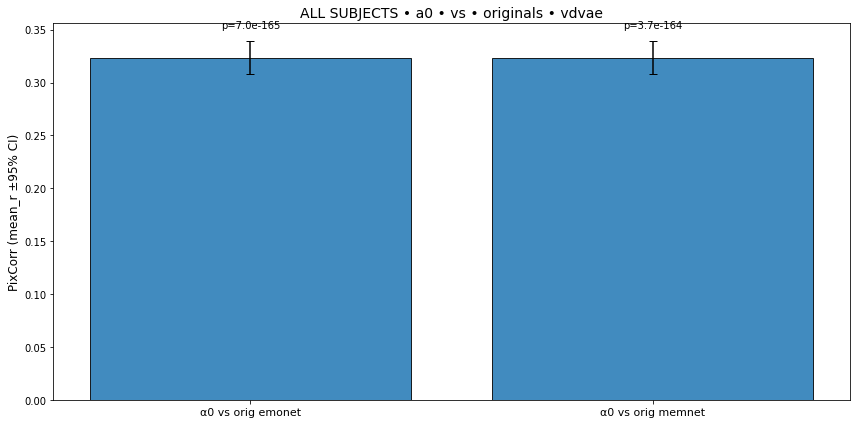

saved: /home/rothermm/brain-diffuser/results/graphs/pix_corr/a0_vs_originals_versatile.png


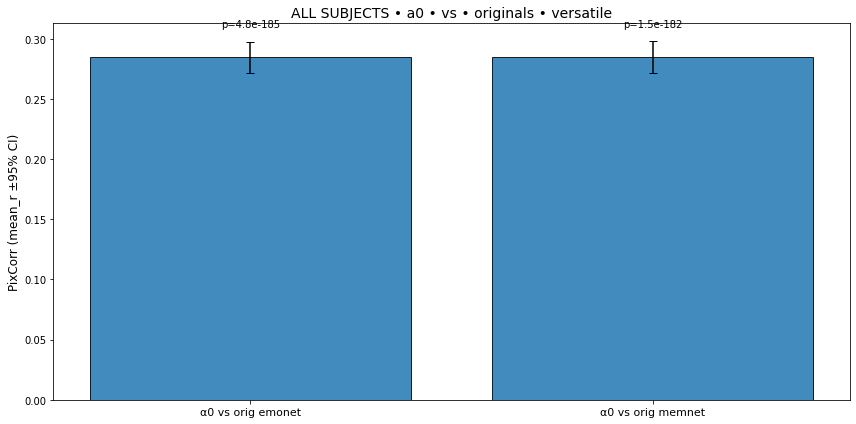

saved: /home/rothermm/brain-diffuser/results/graphs/pix_corr/a0_vs_i2i_vdvae.png


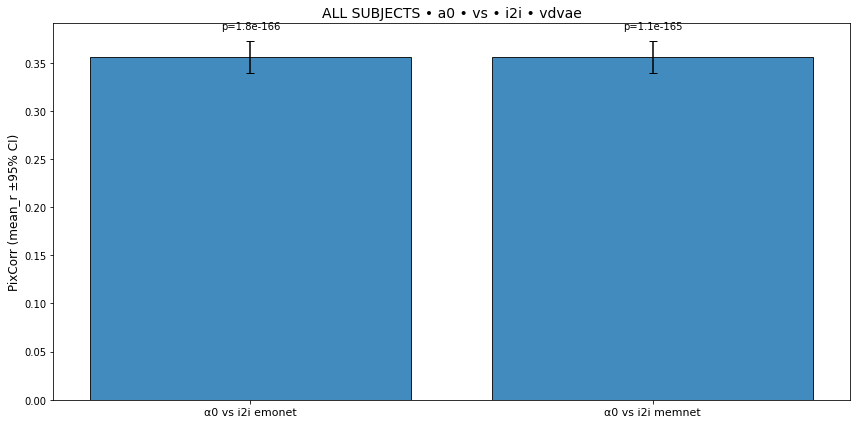

saved: /home/rothermm/brain-diffuser/results/graphs/pix_corr/a0_vs_i2i_versatile.png


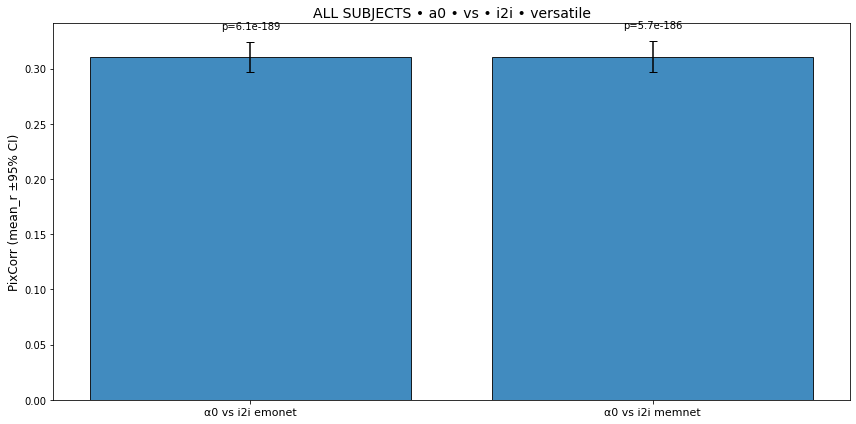

In [24]:
# %% setup
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = Path("/home/rothermm/brain-diffuser/results/metrics/pixcorr")
SUBJECTS = ["subj01","subj02","subj05","subj07"]

# Load all summary.csv
dfs = []
for subj in SUBJECTS:
    f = BASE / subj / "summary.csv"
    d = pd.read_csv(f)
    d["subject"] = subj
    dfs.append(d)
df_all = pd.concat(dfs, ignore_index=True)

# Compute averages across subjects
agg = (
    df_all.groupby("comparison")
    .agg({
        "mean_r": "mean",
        "ci_low_r": "mean",   # note: just averaging CI bounds
        "ci_high_r": "mean",
        "p_value": "mean",    # mean p-value (not strictly correct, but ok for inspection)
        "n": "mean"
    })
    .reset_index()
)

OUT_DIR = Path("/home/rothermm/brain-diffuser/results/graphs/pix_corr")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def short_label(label: str) -> str:
    if "intra:" in label:
        return label.split(":")[-1]
    if "alpha0_vs_originals" in label:
        return "α0 vs orig " + label.split(":")[-1]
    if "alpha0_vs_vdvae_i2i" in label:
        return "α0 vs i2i " + label.split(":")[-1]
    return label

def plot_keys(keys, title, fname=None):
    d = agg[agg["comparison"].isin(keys)].copy()
    if d.empty:
        print(f"[skip] {title} (no rows)")
        return
    d["order"] = d["comparison"].apply(lambda k: keys.index(k))
    d = d.sort_values("order")

    x = np.arange(len(d))
    y = d["mean_r"].values
    yerr = np.vstack([y - d["ci_low_r"].values, d["ci_high_r"].values - y])
    pvals = d["p_value"].values
    labels = [short_label(k) for k in d["comparison"]]

    fig, ax = plt.subplots(figsize=(12,6))
    ax.bar(x, y, yerr=yerr, capsize=4, edgecolor="black", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0, ha="center", fontsize=11)
    ax.set_ylabel("PixCorr (mean_r ±95% CI)", fontsize=12)
    ax.set_title(f"ALL SUBJECTS • {title}", fontsize=14)

    offsets = np.max(yerr, axis=0) if yerr.size else np.zeros_like(y)
    for xi, yi, off, p in zip(x, y, offsets, pvals):
        label = "n/a" if pd.isna(p) else f"p={p:.1e}"
        ax.text(xi, yi + off + 0.01, label, ha="center", va="bottom", fontsize=10)

    fig.tight_layout()
    if fname:
        out_path = OUT_DIR / f"{fname}.png"
        fig.savefig(out_path, dpi=150)
        print(f"saved: {out_path}")
    plt.show()

# %% groups exactly as before

# %% define all groups
groups = {
    "intra_vdvae_emonet": [
        'intra:vdvae:emonet:alpha_-4_vs_alpha_0',
        'intra:vdvae:emonet:alpha_-2_vs_alpha_0',
        'intra:vdvae:emonet:alpha_+2_vs_alpha_0',
        'intra:vdvae:emonet:alpha_+4_vs_alpha_0',
    ],
    "intra_vdvae_memnet": [
        'intra:vdvae:memnet:alpha_-4_vs_alpha_0',
        'intra:vdvae:memnet:alpha_-2_vs_alpha_0',
        'intra:vdvae:memnet:alpha_+2_vs_alpha_0',
        'intra:vdvae:memnet:alpha_+4_vs_alpha_0',
    ],
    "intra_versatile_emonet": [
        'intra:versatile_diffusion:emonet:alpha_-4_vs_alpha_0',
        'intra:versatile_diffusion:emonet:alpha_-2_vs_alpha_0',
        'intra:versatile_diffusion:emonet:alpha_+2_vs_alpha_0',
        'intra:versatile_diffusion:emonet:alpha_+4_vs_alpha_0',
    ],
    "intra_versatile_memnet": [
        'intra:versatile_diffusion:memnet:alpha_-4_vs_alpha_0',
        'intra:versatile_diffusion:memnet:alpha_-2_vs_alpha_0',
        'intra:versatile_diffusion:memnet:alpha_+2_vs_alpha_0',
        'intra:versatile_diffusion:memnet:alpha_+4_vs_alpha_0',
    ],
    "a0_vs_originals_vdvae": [
        'alpha0_vs_originals:vdvae:emonet',
        'alpha0_vs_originals:vdvae:memnet',
    ],
    "a0_vs_originals_versatile": [
        'alpha0_vs_originals:versatile_diffusion:emonet',
        'alpha0_vs_originals:versatile_diffusion:memnet',
    ],
    "a0_vs_i2i_vdvae": [
        'alpha0_vs_vdvae_i2i:vdvae:emonet',
        'alpha0_vs_vdvae_i2i:vdvae:memnet',
    ],
    "a0_vs_i2i_versatile": [
        'alpha0_vs_vdvae_i2i:versatile_diffusion:emonet',
        'alpha0_vs_vdvae_i2i:versatile_diffusion:memnet',
    ],
}

# %% loop over groups and plot+save
for fname, keys in groups.items():
    title = fname.replace("_", " • ")
    plot_keys(keys, title, fname=fname)
